RFM Analysis & Segmentation

Dataset Shape: (10000, 35)

RFM ANALYSIS

 Customer Segmentation Complete:
Segment
Low Value       913
Medium Value    718
High Value      355
Name: count, dtype: int64


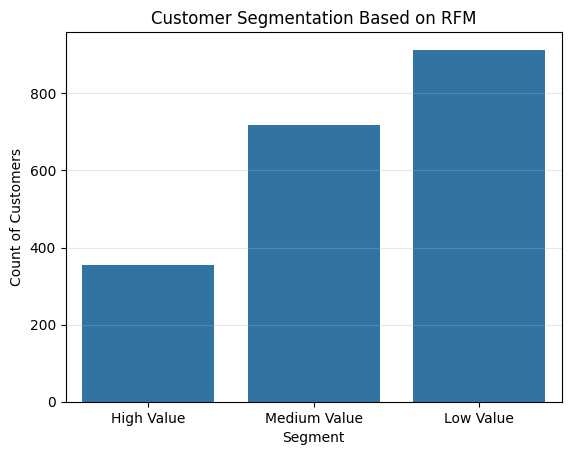

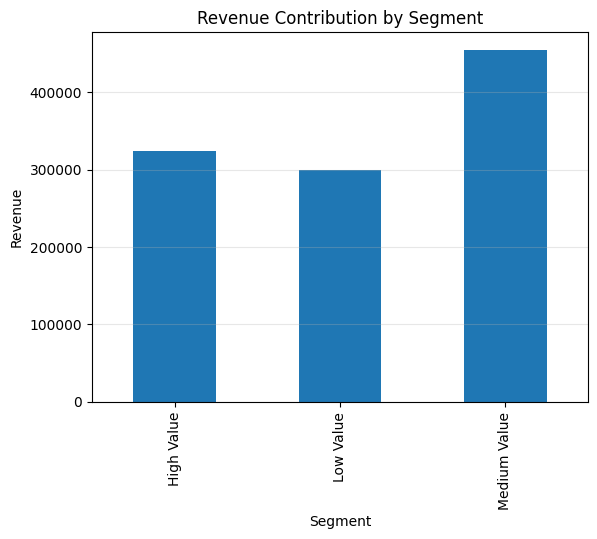


 RFM analysis saved to: data/processed/rfm_analysis.csv


In [17]:
# Retail & Marketing Analytics Project
# Notebook 3: RFM Analysis & CLV

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Notebook: 03 - RFM & CLV Analysis
Part 01 : RFM Analysis

Objective:
- RFM Analysis (Recency, Frequency, Monetary)
- Customer Lifetime Value (CLV) calculation
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/processed/cleaned_retail_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print("="*80)
print("RFM Analysis")
print("="*80)
print(f"\nDataset Shape: {df.shape}")

# ============================================================================
# 2. RFM ANALYSIS (RECENCY, FREQUENCY, MONETARY)
# ============================================================================

print("\n" + "="*80)
print("RFM ANALYSIS")
print("="*80)

analysis_date = df['Order_Date'].max() + timedelta(days=1)

rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (analysis_date - x.max()).days,
    'Order_ID': 'count',
    'Sales': 'sum'
}).reset_index()

rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# RFM Scoring

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels = [5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'],5, labels = [1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5,labels = [1,2,3,4,5])

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int) +
    rfm['F_Score'].astype(int) +
    rfm['M_Score'].astype(int)
)

#Rule-Based Segmentation
def rfm_segment(row):
    if row['RFM_Score'] >= 13:
        return 'High Value'
    elif row['RFM_Score'] >=9:
        return 'Medium Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm.apply(rfm_segment, axis =1)

print("\n Customer Segmentation Complete:")
print(rfm['Segment'].value_counts())

# Visualization

sns.countplot(data = rfm, x='Segment')
plt.title('Customer Segmentation Based on RFM')
plt.xlabel('Segment')
plt.ylabel('Count of Customers')
plt.grid(axis='y', alpha=0.3)
plt.savefig('outputs/figures/15_customer_segmentation.png')
plt.show()
    
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title('Revenue Contribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue')
plt.grid(axis='y', alpha=0.3)
plt.savefig('outputs/figures/16_Revenue_Contribution_by_Segment.png')
plt.show()

# Save RFM analysis
rfm.to_csv('data/processed/rfm_analysis.csv', index=False)
print("\n RFM analysis saved to: data/processed/rfm_analysis.csv")





CUSTOMER LIFETIME VALUE (CLV) CALCULATION
     Customer_ID  Total_Sales  Total_Orders         First_Order  \
0       CUST0001   943.770842             8 2022-02-14 00:00:00   
1       CUST0002   617.531725             6 2022-01-13 00:00:00   
2       CUST0003   548.860692             5 2022-03-28 21:00:00   
3       CUST0004   247.117878             3 2022-02-25 11:00:00   
4       CUST0005   337.341185             4 2022-01-25 05:00:00   
...          ...          ...           ...                 ...   
1981    CUST1995  1097.063156             9 2022-02-17 19:00:00   
1982    CUST1996   597.018436             4 2022-08-02 09:00:00   
1983    CUST1997   853.534870             7 2022-02-07 18:00:00   
1984    CUST1998   893.044077             7 2022-01-28 02:00:00   
1985    CUST1999   425.161459             4 2022-01-11 23:00:00   

              Last_Order  Customer_Lifespan_Years  Avg_Order_Value  \
0    2023-01-14 04:00:00                 0.915068       117.971355   
1    2023-01

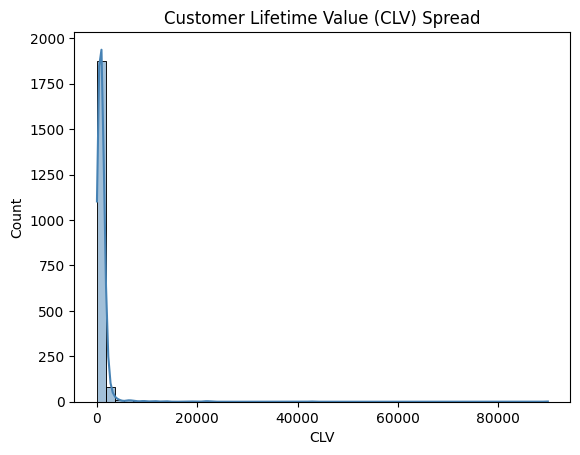


 CLV data saved to: data/processed/customer_clv.csv

NOTEBOOK 03 COMPLETED SUCCESSFULLY!

✅ Next Step: Open Notebook 04 - KPI Design and Dashboard Preparation


In [18]:
"""
Part 02 : Customer Lifetime Value (CLV) calculation

"""
# ============================================================================
# 3. CUSTOMER LIFETIME VALUE (CLV)
# ============================================================================

print("\n" + "="*80)
print("CUSTOMER LIFETIME VALUE (CLV) CALCULATION")
print("="*80)

# Calculate CLV components
clv = df.groupby('Customer_ID').agg({
    'Sales':'sum',
    'Order_ID':'count',
    'Order_Date':['min','max']
}).reset_index()

clv.columns = ['Customer_ID', 'Total_Sales', 'Total_Orders', 'First_Order', 'Last_Order']

# Calculate customer lifespan
clv['Customer_Lifespan_Years'] = ((clv['Last_Order'] - clv['First_Order']).dt.days / 365).replace(0,1)

# Calculate metrics
clv['Avg_Order_Value'] = clv['Total_Sales'] / clv['Total_Orders']
clv['Purchase_Frequency'] = clv['Total_Orders'] / clv['Customer_Lifespan_Years']

# CLV Calculation
clv['CLV'] = clv['Avg_Order_Value'] * clv['Purchase_Frequency']

print(clv)

# Visualization

sns.histplot(data=clv, x='CLV', bins = 50, kde=True, color='steelblue')
plt.title('Customer Lifetime Value (CLV) Spread')
plt.xlabel('CLV')
plt.savefig('outputs/figures/17_CLV_Distribution.png')
plt.show()

# Save CLV data
clv.to_csv('data/processed/customer_clv.csv', index=False)
print("\n CLV data saved to: data/processed/customer_clv.csv")

print("\n" + "="*80)
print("NOTEBOOK 03 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Open Notebook 04 - KPI Design and Dashboard Preparation")
print("="*80)